<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning - 2301CS621</b></center>
<center><b><h1>Name:-Karan Songara || Date: 13/01/2026 || Enrollment:-24010101694</b></center>  
<center><b><h1>Lab - 8</b></center>    
<pre>    

# Do all pre processing on diabetes csv

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import tree 
import seaborn as sns

# Import diabetes.csv data ser using sklearn

In [7]:
df = pd.read_csv("diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,Diabetic
1,1,85,66,29,0,26.6,0.351,31,Non Diabetic
2,8,183,64,0,0,23.3,0.672,32,Diabetic
3,1,89,66,23,94,28.1,0.167,21,Non Diabetic
4,0,137,40,35,168,43.1,2.288,33,Diabetic
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,Non Diabetic
764,2,122,70,27,0,36.8,0.340,27,Non Diabetic
765,5,121,72,23,112,26.2,0.245,30,Non Diabetic
766,1,126,60,0,0,30.1,0.349,47,Diabetic


# Check the distribution of the target

In [9]:
df['Outcome'].value_counts()

Outcome
Non Diabetic    500
Diabetic        268
Name: count, dtype: int64

# Replace zeros with NaN for specific columns

In [16]:
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)
print(cols_with_zero)

['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']


# Check for missing values

In [ ]:
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

# Fill missing values with median

In [22]:
for col in cols_with_zero:
    df[col].fillna(df[col].median(), inplace=True)

print(col)


BMI


C:\Users\karan\AppData\Local\Temp\ipykernel_24744\3301112694.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [ ]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

# Convert Targer data into interger code

In [20]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Outcome'] = le.fit_transform(df['Outcome'])
df['Outcome'].fillna(0, inplace=True)


C:\Users\karan\AppData\Local\Temp\ipykernel_24744\1229847219.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Outcome'].fillna(0, inplace=True)


In [24]:
df['Outcome'] = df['Outcome'].astype(int)
df.dtypes
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,0
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,1
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,0
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,1
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,0
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,1
764,2,122.0,70.0,27.0,125.0,36.8,0.340,27,1
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,1
766,1,126.0,60.0,29.0,125.0,30.1,0.349,47,0


# Visualize Distributions

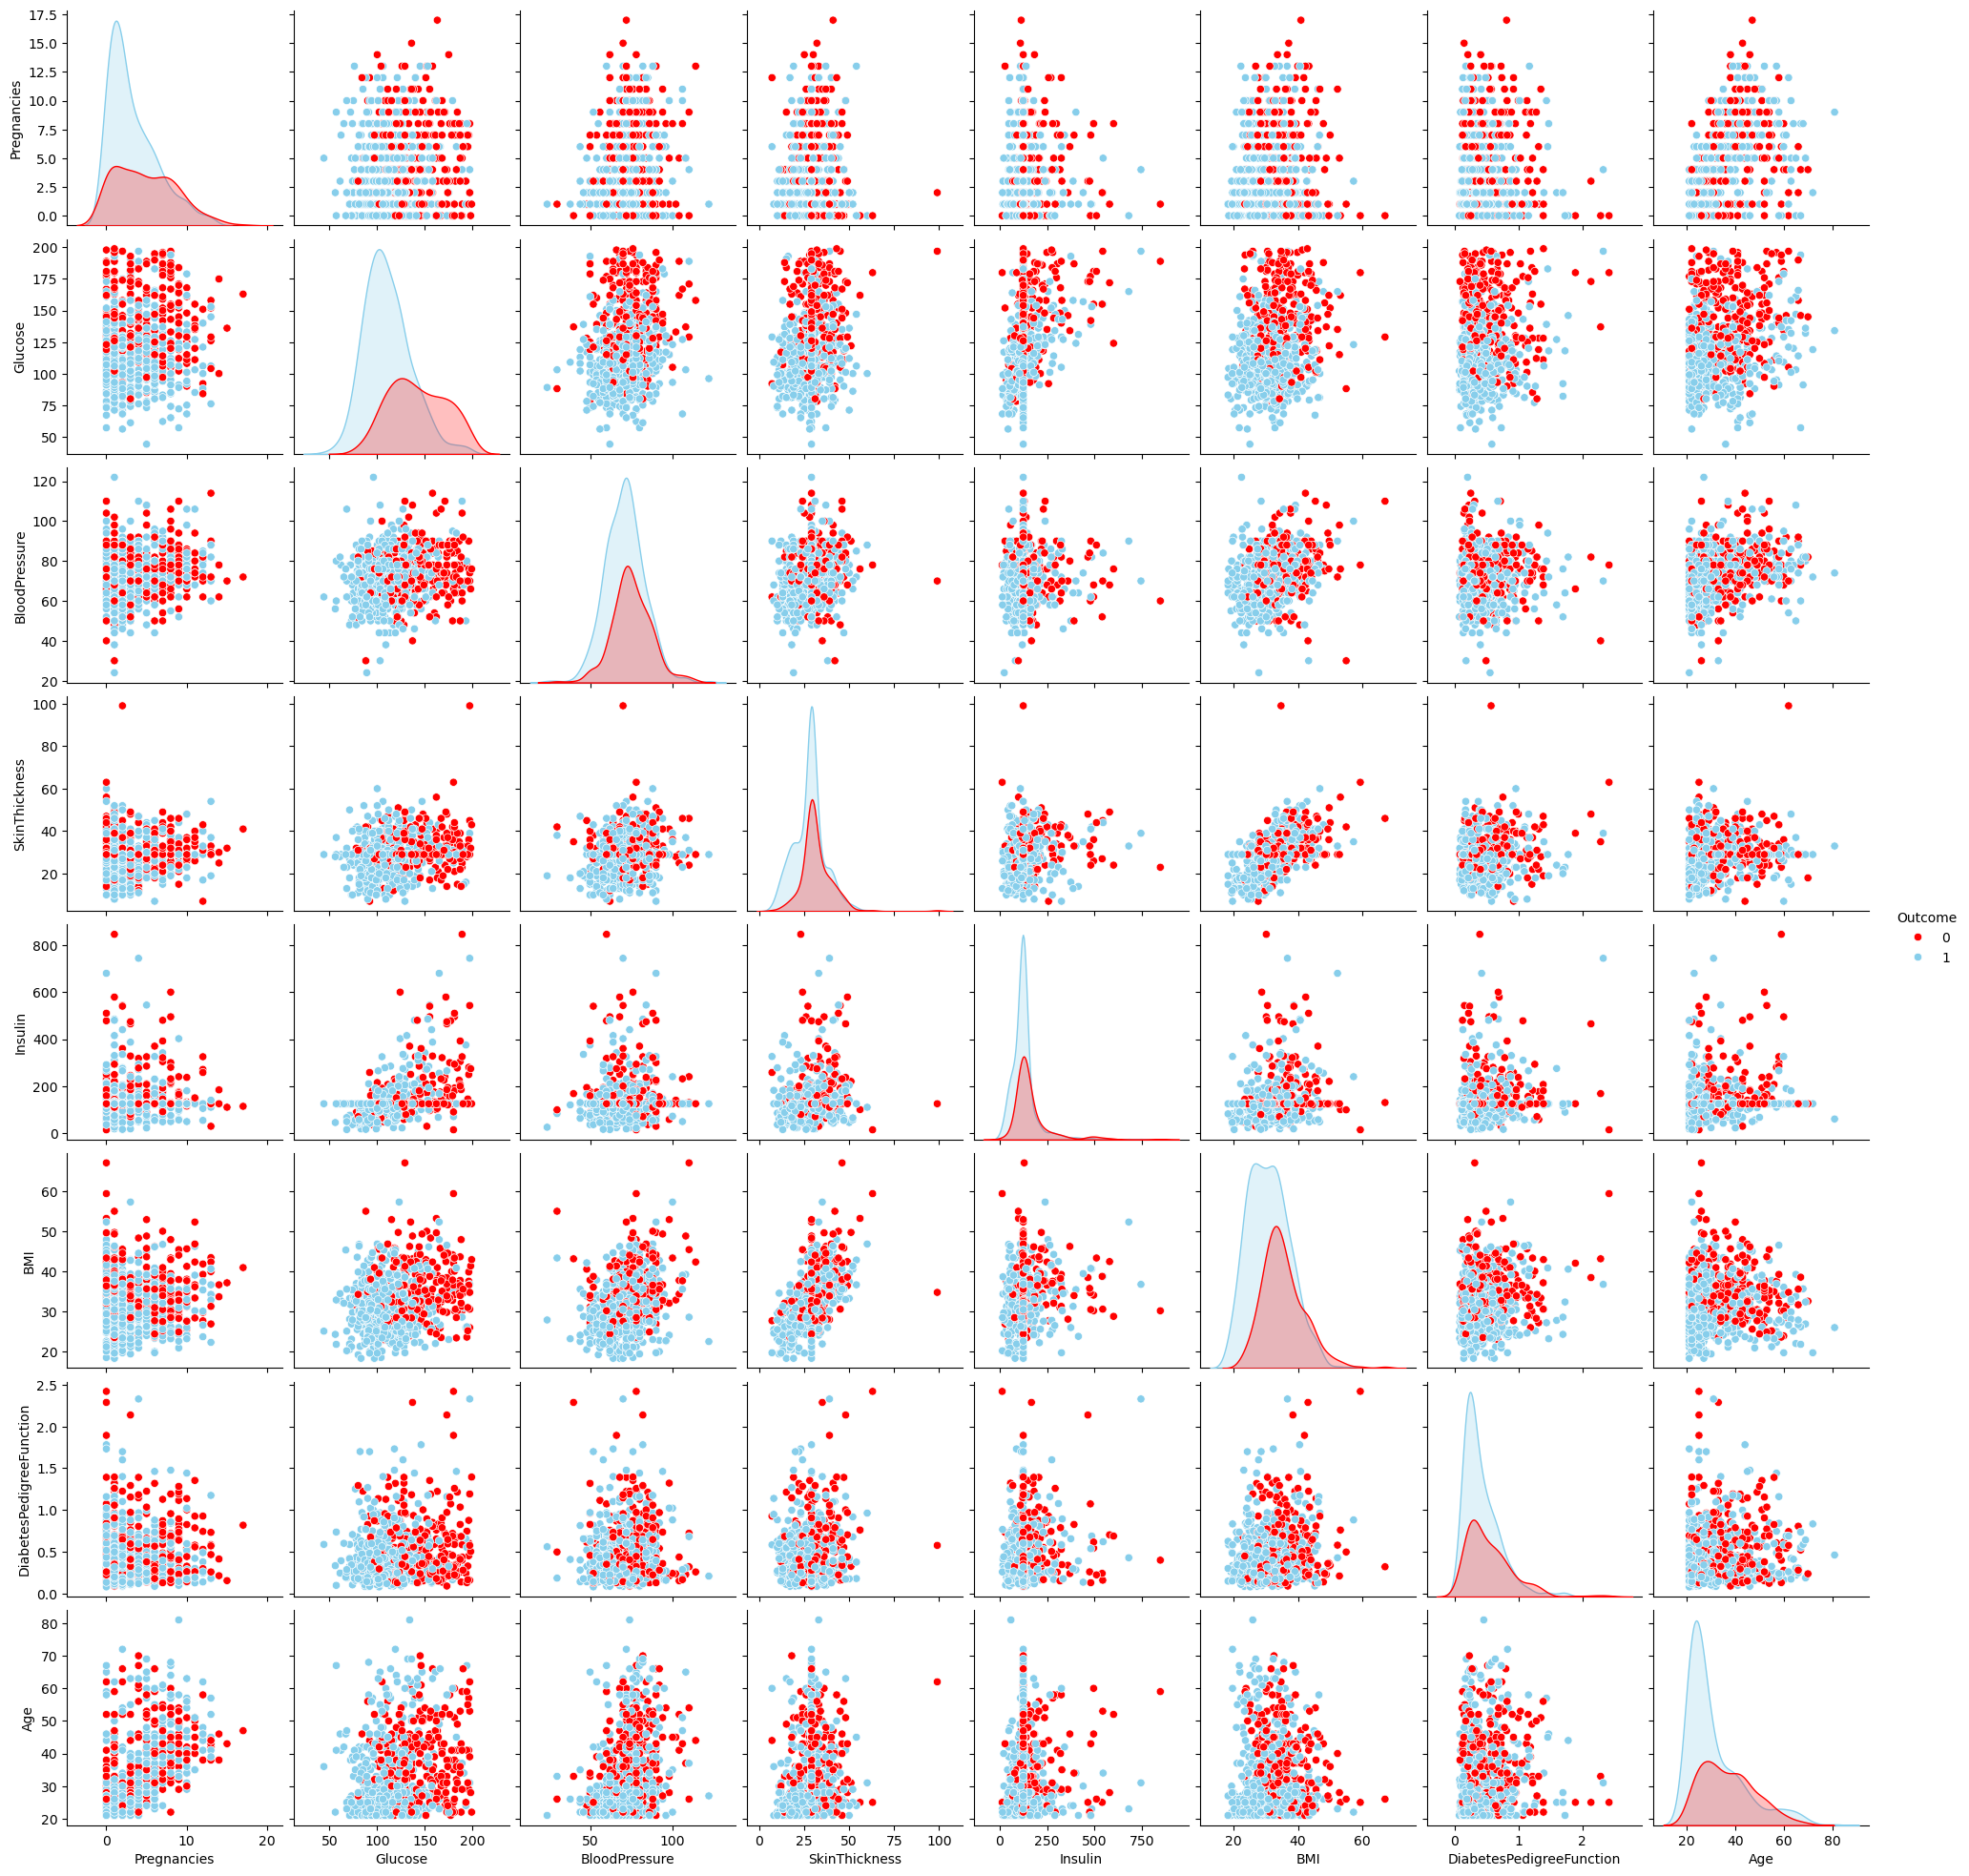

In [26]:
sns.pairplot(
    df.select_dtypes(include="number"),
    hue="Outcome",
    diag_kind="kde",
        palette=
    {
        0:"red",
        1:"skyblue"
    }
)
plt.show()

<Axes: >

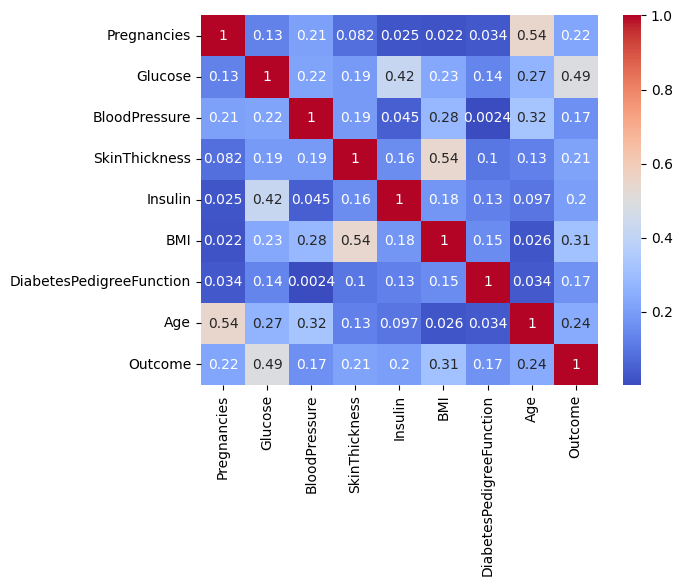

In [43]:
sns.heatmap(df.corr() .abs(), annot=True, cmap='coolwarm')


In [44]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,0
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,1
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,0
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,1
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,0
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,1
764,2,122.0,70.0,27.0,125.0,36.8,0.340,27,1
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,1
766,1,126.0,60.0,29.0,125.0,30.1,0.349,47,0


# Divide the data into input and output

In [28]:
x=df.iloc[::,:-1:]

In [30]:
y=df['Outcome']

# import KNN Model

In [70]:
from sklearn.neighbors import KNeighborsClassifier

# Splitting the dataset into the Training set and Test set

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42,
)

# Convert all features into Z score

In [76]:
from sklearn.preprocessing import StandardScaler, LabelEncoder


In [78]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [80]:
X_train

array([[-0.8362943 , -0.89454593, -1.00322115, ..., -1.20382556,
        -0.61421636, -0.94861028],
       [ 0.39072767, -0.56247683, -0.01909007, ...,  0.66449801,
        -0.90973787, -0.43466673],
       [-1.14304979,  0.43373048, -0.34713376, ...,  1.44057087,
        -0.30699103, -0.77729576],
       ...,
       [ 1.92450513, -0.69530447,  1.12906286, ...,  1.91483763,
         1.94892066,  0.42190587],
       [-1.14304979,  0.63297195, -0.01909007, ...,  1.45494259,
        -0.77514391, -0.34900947],
       [-1.14304979,  0.10166138,  1.9491721 , ..., -1.40502964,
        -0.60836445, -1.03426754]])

In [82]:
X_test

array([[ 0.69748316, -0.7949252 , -1.167243  , ...,  0.24771813,
        -0.11680393,  0.85019217],
       [-0.52953881, -0.33002846,  0.2269427 , ...,  0.49203737,
        -0.94192338, -1.03426754],
       [-0.52953881, -0.4628561 , -0.67517745, ..., -0.2121769 ,
        -0.91266382, -1.03426754],
       ...,
       [-1.14304979,  0.1680752 ,  0.63699732, ...,  0.57826769,
         0.97750343, -0.86295302],
       [ 0.69748316, -0.56247683, -0.18311191, ..., -0.2121769 ,
        -1.01799822,  0.33624861],
       [ 0.39072767, -1.49227032,  0.80101917, ...,  0.50640909,
        -0.91851573,  0.16493409]])

# Create KNN Model

In [85]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = [1, 23, 537]
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    comment = ""
    suffix = ""
    if k == 1:
        comment = "(Sensitive to noise)"
    elif k == 23:
        comment = "(Square Root Rule)"
        suffix = " <--- Balanced"
    elif k == 537:
        comment = "(Too smooth)"
    
    print(f"Accuracy with k={k} {comment}: {acc:.4f}{suffix}")


Accuracy with k=1 (Sensitive to noise): 0.6667
Accuracy with k=23 (Square Root Rule): 0.7489 <--- Balanced
Accuracy with k=537 (Too smooth): 0.6537


# Fitting KNN   on dataset

In [88]:
knn.fit(X_train,y_train)


KNeighborsClassifier(n_neighbors=537)

In [90]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

accuracy = knn.score(X_test, y_test)
accuracy


0.7056277056277056

# Display classification_report

In [112]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,classification_report,accuracy_score

In [114]:
y_prdict=knn.predict(X_test)

In [116]:
print("Accuracy:", accuracy_score(y_test, y_prdict))
print("\nClassification Report:\n", classification_report(y_test, y_prdict))

Accuracy: 0.7056277056277056

Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.64      0.60        80
           1       0.79      0.74      0.77       151

    accuracy                           0.71       231
   macro avg       0.68      0.69      0.68       231
weighted avg       0.72      0.71      0.71       231



In [122]:
y_predict = model.predict(X_test)

cm = confusion_matrix(y_test,y_predict)

display = ConfusionMatrixDisplay(cm , display_labels=['0','1'])

display.plot()

NotFittedError: This KNeighborsClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [49]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.651042
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,1.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# Method to decide best Value of K is Square Root of N

In [ ]:
import math

In [124]:
n_train_samples = len(x_train)
k_sqrt = int(math.sqrt(n_train_samples))

# Ensure k is odd to avoid ties in binary classification
if k_sqrt % 2 == 0:
    k_sqrt += 1

print(f"Training samples: {n_train_samples}")
print(f"Calculated k (sqrt(n)): {k_sqrt}\n")

NameError: name 'x_train' is not defined

Accuracy with k=1 (Sensitive to noise): 0.7100
Accuracy with k=23 (Square Root Rule):   0.7619 <--- Balanced
Accuracy with k=537 (Too smooth):       0.6797


# Hyper parameter tuning using gridsearchcv

In [39]:
from sklearn.model_selection import GridSearchCV

In [38]:
parameters = {'n_neighbors':(1,2,3,4,5,6,7,8,9,10,11),'weights':('uniform', 'distance')}

GridSearchCV(estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': (1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11),
                         'weights': ('uniform', 'distance')})

{'n_neighbors': 11, 'weights': 'uniform'}

0.7656650539003481

KNeighborsClassifier(n_neighbors=11)

{'mean_fit_time': array([0.0015532 , 0.00085506, 0.00057263, 0.00045662, 0.0004519 ,
        0.00045395, 0.00045438, 0.00045342, 0.00045295, 0.00045443,
        0.00045152, 0.00045686, 0.00045309, 0.00045485, 0.0004529 ,
        0.00045919, 0.00055366, 0.00052924, 0.00055528, 0.00051055,
        0.00046563, 0.00046191]),
 'std_fit_time': array([7.36628386e-04, 1.01100341e-04, 4.22888700e-05, 3.02105600e-06,
        2.65320353e-06, 5.67015323e-06, 2.43793927e-06, 4.53221114e-06,
        3.05101266e-06, 5.19073988e-06, 2.05317022e-06, 1.32894781e-05,
        4.12016002e-06, 3.22491425e-06, 1.09361123e-06, 1.48968690e-05,
        1.09285875e-04, 8.09783220e-05, 1.39654118e-04, 6.88277068e-05,
        4.43484193e-06, 3.33308832e-06]),
 'mean_score_time': array([0.00804839, 0.00191269, 0.00411897, 0.0012064 , 0.00345235,
        0.0012476 , 0.00349941, 0.00129676, 0.00351477, 0.00133276,
        0.00356021, 0.00137362, 0.00357466, 0.00140767, 0.0036119 ,
        0.00143943, 0.00418344, 0.00

In [47]:
# Randomstate = 1
# Test size 0.3
# 